In [ ]:
from pathlib import Path

def find_project_root(start=None, markers=("run_all.py", "requirements.txt")):
    p = Path(start or Path.cwd()).resolve()
    for candidate in (p, *p.parents):
        if any((candidate / m).exists() for m in markers):
            return candidate
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"
TEMP_DIR = PROJECT_ROOT / "temp"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

# Read the Yellow Pages match rates CSV (created by 2_build_match_rate_flags.ipynb)
FIGURES_DIR = OUTPUT_DIR / "2_analysis/figures/analyze_yellowpages_website_matching"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = OUTPUT_DIR / "2_analysis/tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_DIR / "1_derived/4_scrape_yellowpages/2_match_rates.csv", low_memory=False)

In [2]:
# Preview the data
print(f"Total rows in dataset: {len(df)}")
df

Total rows in dataset: 38135


,clean_line1,clean_line2,line3,city,zip_code,label,phone,year,major_city,state,...,Tertiary_Road,phone_scraped_matches_row_ids,ZIP_scraped_matches_row_ids,City_scraped_matches_row_ids,Exit_scraped_matches_row_ids,State_scraped_matches_row_ids,Road_scraped_matches_row_ids,Chain_scraped_matches_row_ids,Label_scraped_matches_row_ids,all_matches
0,"Blandford , 01008 Blandford Plaza EB Exxon # 5020",413-848-2056 I-90 ( MATP ) MM 29 EB,<U+25A1> <U+2610>,Blandford,1008,Blandford Plaza EB Exxon # 5020,413-848-2056,2006,Blandford,MA,...,None,"[10517, 2750]",[],"[10518, 10517, 2750, 2751]",[],"[2746, 2747, 2748, 2749, 2750, 2751, 2752, 275...","[12291, 2054, 12304, 2065, 12306, 14355, 2068,...","[14337, 6146, 4, 6148, 6150, 14347, 14350, 143...","[14337, 6146, 4, 6148, 6150, 14347, 14350, 143...","[4, 8221, 8223, 8227, 36, 8229, 44, 8244, 54, ..."
1,"Blandford , 01008 Blandford Plaza EB Exxon # 5020",413-848-2056 I-90 ( MATP ) MM 29 EB,24 HRS S,Blandford,1008,Blandford Plaza EB Exxon # 5020,413-848-2056,2007,Blandford,MA,...,None,"[10517, 2750]",[],"[10518, 10517, 2750, 2751]",[],"[2746, 2747, 2748, 2749, 2750, 2751, 2752, 275...","[12291, 2054, 12304, 2065, 12306, 14355, 2068,...","[14337, 6146, 4, 6148, 6150, 14347, 14350, 143...","[14337, 6146, 4, 6148, 6150, 14347, 14350, 143...","[4, 8221, 8223, 8227, 36, 8229, 44, 8244, 54, ..."
2,"Blandford , 01008 Blandford Plaza EB Exxon # 5020",413-848-2056 I-90 ( MATP ) MM 29 EB,HAS 24 SO <U+2610> <U+2610>,Blandford,1008,Blandford Plaza EB Exxon # 5020,413-848-2056,2008,Blandford,MA,...,None,"[10517, 2750]",[],"[10518, 10517, 2750, 2751]",[],"[2746, 2747, 2748, 2749, 2750, 2751, 2752, 275...","[12291, 2054, 12304, 2065, 12306, 14355, 2068,...","[14337, 6146, 4, 6148, 6150, 14347, 14350, 143...","[14337, 6146, 4, 6148, 6150, 14347, 14350, 143...","[4, 8221, 8223, 8227, 36, 8229, 44, 8244, 54, ..."
3,D Blandford ( 01008 ) Blandford Plaza EB # 902...,413-848-2056 I-90 ( MATP ) MM 29 EB,24 S <U+2610>,Blandford,1008,Blandford Plaza EB # 9020 ( Gulf ),413-848-2056,2014,Blandford,MA,...,None,"[10517, 2750]",[],"[10518, 10517, 2750, 2751]",[],"[2746, 2747, 2748, 2749, 2750, 2751, 2752, 275...","[12291, 2054, 12304, 2065, 12306, 14355, 2068,...","[14874, 4658, 59, 62, 2633, 12370, 7272, 4208,...","[14874, 4658, 59, 11836, 62, 2633, 12370, 7272...","[15061, 8141, 12291, 2054, 12304, 2065, 12306,..."
4,D Blandford ( 01008 ) Blandford Plaza EB # 902...,2 413-848-2056 I-90 ( MATP ) MM 29 EB,24 S,Blandford,1008,Blandford Plaza EB # 9020 ( Gulf ),413-848-2056,2015,Blandford,MA,...,None,"[10517, 2750]",[],"[10518, 10517, 2750, 2751]",[],"[2746, 2747, 2748, 2749, 2750, 2751, 2752, 275...","[12291, 2054, 12304, 2065, 12306, 14355, 2068,...","[14874, 4658, 59, 62, 2633, 12370, 7272, 4208,...","[14874, 4658, 59, 11836, 62, 2633, 12370, 7272...","[15061, 8141, 12291, 2054, 12304, 2065, 12306,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38130,"C Tok , 99780 Village Gas",6 907-883-4660 AK 1 ( MM 1313.2 ),None,Tok,99780,Village Gas,907-883-4660,2007,Tok,AK,...,None,[],"[7924, 7927, 15522, 15525]","[15522, 7924, 15525, 7927]",[],"[7907, 7908, 7909, 7910, 7911, 7912, 7913, 791...","[2048, 12290, 2075, 6181, 14404, 10315, 14416,...",[],[],"[2048, 12290, 2075, 6181, 14404, 10315, 14416,..."
38131,"C Tok , 99780 Village Gas",6 907-883-4660 AK 1 ( MM 1313.2 ),<U+25C9>,Tok,99780,Village Gas,907-883-4660,2008,Tok,AK,...,None,[],"[7924, 7927, 15522, 15525]","[15522, 7924, 15525, 7927]",[],"[7907, 7908, 7909, 7910, 7911, 7912, 7913, 791...","[2048, 12290, 2075, 6181, 14404, 10315, 14416,...",[],[],"[2048, 12290, 2075, 6181, 14404, 10315, 14416,..."
38132,"Tok , 99780 Plaza Truck Stop ( Texaco )",907-883-5833 AK Hwy 2 ( MM 1313.5 ),None,Tok,99780,Plaza Truck Stop ( Texaco ),907-883-5833,2006,Tok,AK,...,None,[],"[7924, 7927, 15522, 15525]","[15522, 7924, 15525, 7927]",[],"[7907, 7908, 7909, 7910, 7911, 7912, 7913, 791...","[4097, 4108, 4123, 4132, 6187, 4141, 4153, 415...","[3586,

# 1. Phone number match analysis

We'll analyze how much of our data contains phone number matches.

In [3]:
# Function to safely evaluate string representation of lists
def safe_eval(s):
    try:
        if isinstance(s, str):
            return ast.literal_eval(s)
        return s
    except (ValueError, SyntaxError):
        return []

# Apply the safe_eval function to phone_scraped_matches_row_ids column
df['phone_matches'] = df['phone_scraped_matches_row_ids'].apply(safe_eval)

# Check if the list is empty or not
df['has_phone_match'] = df['phone_matches'].apply(lambda x: len(x) > 0)

# Count rows with and without phone matches
rows_with_phone = np.sum(df['has_phone_match'])
rows_without_phone = len(df) - rows_with_phone

# Calculate percentages
total_rows = len(df)
percent_with_phone = (rows_with_phone / total_rows) * 100
percent_without_phone = (rows_without_phone / total_rows) * 100

print(f"Rows with phone matches: {rows_with_phone} ({percent_with_phone:.2f}%)")
print(f"Rows without phone matches: {rows_without_phone} ({percent_without_phone:.2f}%)")
print(f"Total rows: {total_rows}")

Rows with phone matches: 29206 (76.59%)
Rows without phone matches: 8929 (23.41%)
Total rows: 38135


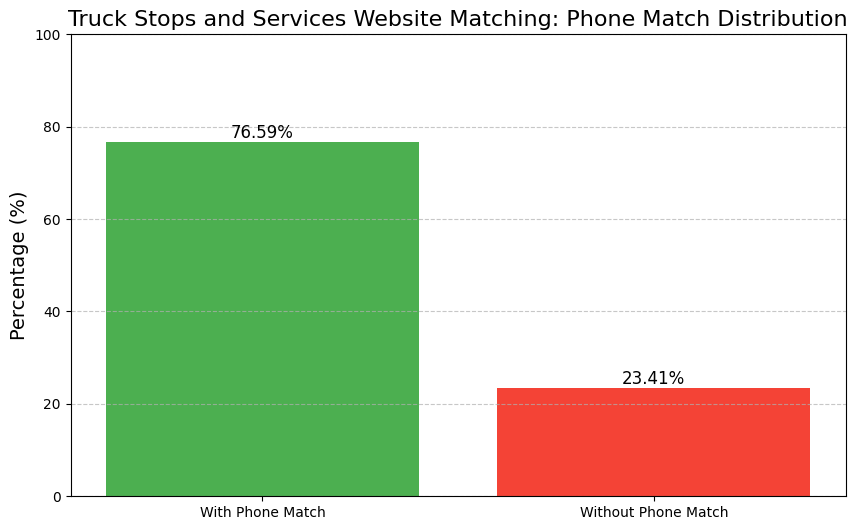

In [4]:
# Visualize phone match distribution
plt.figure(figsize=(10, 6))
labels = ['With Phone Match', 'Without Phone Match']
values = [percent_with_phone, percent_without_phone]
colors = ['#4CAF50', '#F44336']  # Green and Red

plt.bar(labels, values, color=colors)
plt.title('Truck Stops and Services Website Matching: Phone Match Distribution', fontsize=16)
plt.ylabel('Percentage (%)', fontsize=14)
plt.ylim(0, 100)

# Add percentage labels on the bars
for i, v in enumerate(values):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(FIGURES_DIR / 'analyze_yellowpages_website_matching_phone_match_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Match success using address components

We'll assess how data can be matched using component hierarchy when phone numbers are unavailable:
1. ZIP code / State
2. City / Exit
3. Road
4. Label
5. Chain

In [5]:
# Apply safe_eval to all match columns
match_columns = [
    'ZIP_scraped_matches_row_ids',
    'State_scraped_matches_row_ids',
    'City_scraped_matches_row_ids',
    'Exit_scraped_matches_row_ids',
    'Road_scraped_matches_row_ids',
    'Label_scraped_matches_row_ids',
    'Chain_scraped_matches_row_ids'
]

for col in match_columns:
    df[col + '_parsed'] = df[col].apply(safe_eval)

In [6]:
# Function to determine match success rate based on the sequence
def determine_match_success(row):
    # Start with ZIP/State
    match_set = set()
    match_set.update(row['ZIP_scraped_matches_row_ids_parsed'])
    match_set.update(row['State_scraped_matches_row_ids_parsed'])
    
    if not match_set:
        return "0/6 successful match"
    
    # Check City/Exit
    city_exit_set = set()
    city_exit_set.update(row['City_scraped_matches_row_ids_parsed'])
    city_exit_set.update(row['Exit_scraped_matches_row_ids_parsed'])
    
    # Find common elements between match_set and city_exit_set
    match_set = match_set.intersection(city_exit_set) if city_exit_set else match_set
    
    if not match_set:
        return "2/6 successful match"  # Only ZIP/State matched
    
    # Check Road
    road_set = set(row['Road_scraped_matches_row_ids_parsed'])
    match_set = match_set.intersection(road_set) if road_set else match_set
    
    if not match_set:
        return "4/6 successful match"  # ZIP/State and City/Exit matched
    
    # Check Label
    label_set = set(row['Label_scraped_matches_row_ids_parsed'])
    match_set = match_set.intersection(label_set) if label_set else match_set
    
    if not match_set:
        return "5/6 successful match"  # ZIP/State, City/Exit, and Road matched
    
    # Finally check Chain
    chain_set = set(row['Chain_scraped_matches_row_ids_parsed'])
    match_set = match_set.intersection(chain_set) if chain_set else match_set
    
    if not match_set:
        return "6/6 successful match"  # ZIP/State, City/Exit, Road, and Label matched
    
    return "7/6 successful match"  # All components matched

# Apply the function to each row
df['Success_Match_Rate'] = df.apply(determine_match_success, axis=1)

# Add Phone Success Match Rate column
df['Phone_Success_Match_Rate'] = df['has_phone_match']

# Show distribution of match success rates
success_counts = df['Success_Match_Rate'].value_counts().sort_index()
print("Distribution of Match Success Rates:")
print(success_counts)
print("\nPercentage Distribution:")
success_percentages = (success_counts / len(df) * 100).round(2)
print(success_percentages)

Distribution of Match Success Rates:
Success_Match_Rate
0/6 successful match       92
2/6 successful match     1104
4/6 successful match     1727
5/6 successful match     8156
6/6 successful match     3947
7/6 successful match    23109
Name: count, dtype: int64

Percentage Distribution:
Success_Match_Rate
0/6 successful match     0.24
2/6 successful match     2.89
4/6 successful match     4.53
5/6 successful match    21.39
6/6 successful match    10.35
7/6 successful match    60.60
Name: count, dtype: float64


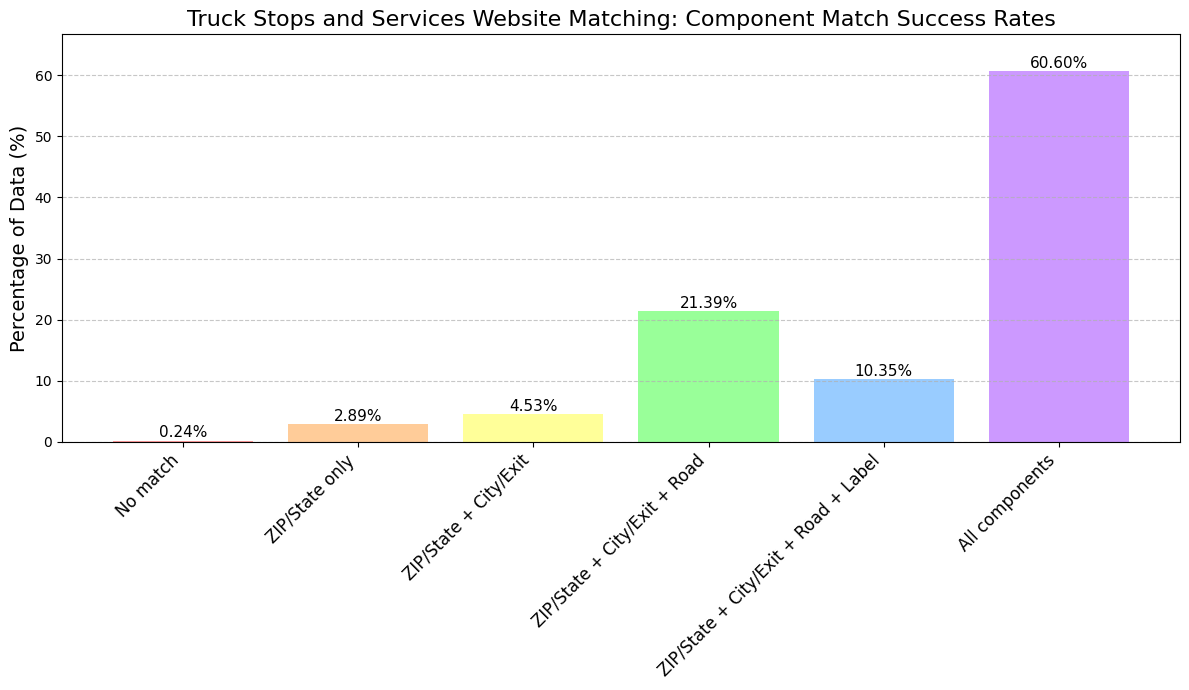

In [7]:
# Visualize the success rates
plt.figure(figsize=(12, 7))

# Define the ordered success levels
success_levels = {
    '0/6 successful match': 'No match',
    '2/6 successful match': 'ZIP/State only',
    '4/6 successful match': 'ZIP/State + City/Exit',
    '5/6 successful match': 'ZIP/State + City/Exit + Road',
    '6/6 successful match': 'ZIP/State + City/Exit + Road + Label',
    '7/6 successful match': 'All components'
}

# Sort by the match level
success_counts = success_counts.reindex(success_levels.keys(), fill_value=0)
success_percentages = success_percentages.reindex(success_levels.keys(), fill_value=0)

# Plot with better labels
bars = plt.bar(
    [success_levels.get(rate, rate) for rate in success_counts.index], 
    success_percentages.values,
    color=['#FF9999', '#FFCC99', '#FFFF99', '#99FF99', '#99CCFF', '#CC99FF']
)

plt.title('Truck Stops and Services Website Matching: Component Match Success Rates', fontsize=16)
plt.ylabel('Percentage of Data (%)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylim(0, max(success_percentages.values) * 1.1)  # Add some space above bars

# Add percentage labels on the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%',
             ha='center', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_yellowpages_website_matching_component_match_success_rates.png', dpi=300, bbox_inches='tight')
plt.show()

Percentage of Success Match Rates by Phone Match Status:
Success_Match_Rate  0/6 successful match  2/6 successful match  \
has_phone_match                                                  
False                               0.19                 11.30   
True                                0.26                  0.33   

Success_Match_Rate  4/6 successful match  5/6 successful match  \
has_phone_match                                                  
False                              12.64                 42.05   
True                                2.05                 15.07   

Success_Match_Rate  6/6 successful match  7/6 successful match  
has_phone_match                                                 
False                               4.51                 29.30  
True                               12.13                 70.17  


<Figure size 1400x800 with 0 Axes>

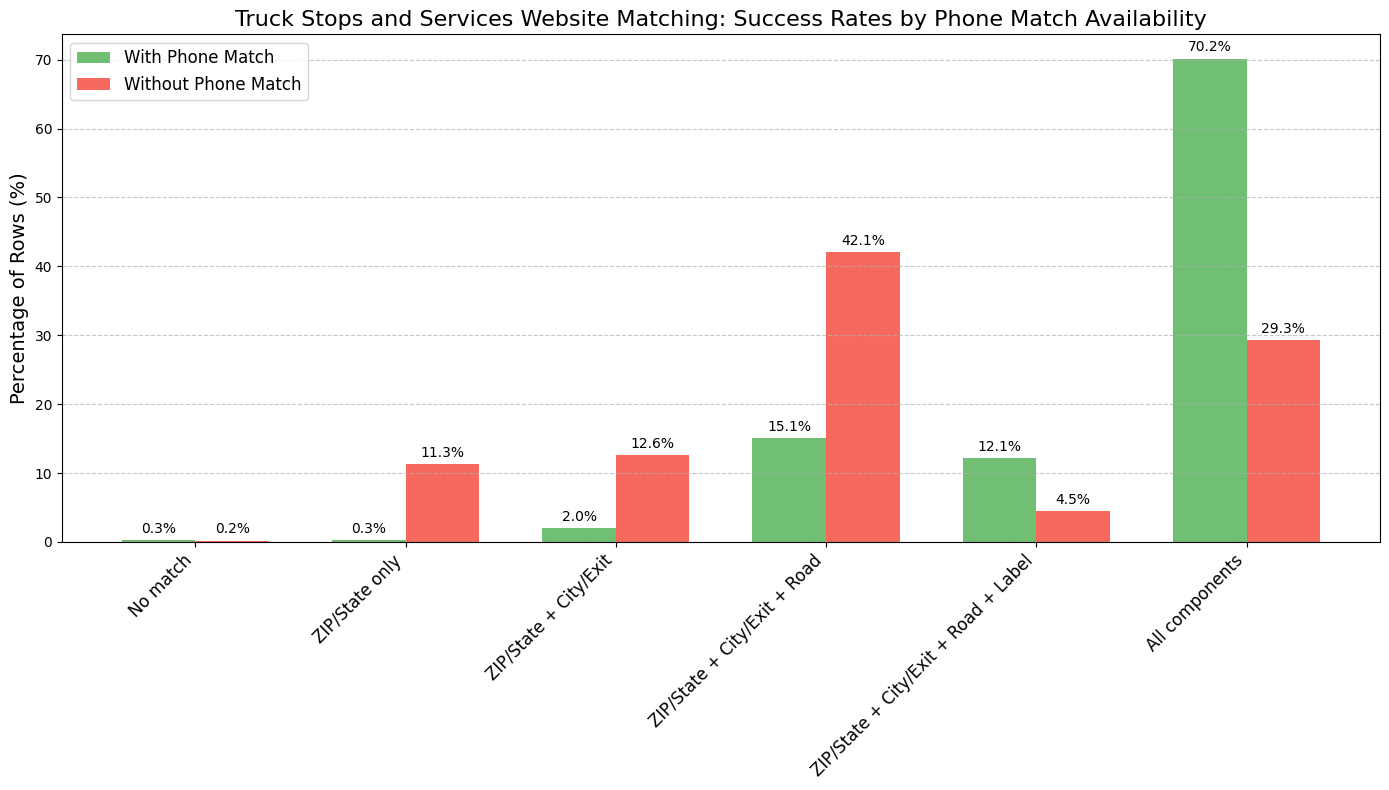

In [8]:
# Analyze relationship between phone matches and address component success rates
phone_vs_component = pd.crosstab(df['has_phone_match'], df['Success_Match_Rate'], normalize='index') * 100
print("Percentage of Success Match Rates by Phone Match Status:")
print(phone_vs_component.round(2))

# Create a grouped bar chart to compare
plt.figure(figsize=(14, 8))

# Get success rates for rows with and without phone matches
with_phone = phone_vs_component.loc[True].reindex(success_levels.keys(), fill_value=0)
without_phone = phone_vs_component.loc[False].reindex(success_levels.keys(), fill_value=0)

x = np.arange(len(success_levels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
bars1 = ax.bar(x - width/2, with_phone, width, label='With Phone Match', color='#4CAF50', alpha=0.8)
bars2 = ax.bar(x + width/2, without_phone, width, label='Without Phone Match', color='#F44336', alpha=0.8)

ax.set_title('Truck Stops and Services Website Matching: Success Rates by Phone Match Availability', fontsize=16)
ax.set_ylabel('Percentage of Rows (%)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([success_levels.get(rate, rate) for rate in success_levels.keys()], rotation=45, ha='right', fontsize=12)
ax.legend(fontsize=12)

# Add percentage labels on the bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        if height > 0:  # Only add labels for non-zero values
            ax.annotate(f'{height:.1f}%',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10)

add_labels(bars1)
add_labels(bars2)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_yellowpages_website_matching_phone_vs_component_grouped_bar.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Save the results to a new CSV file
tables_dir = OUTPUT_DIR / "2_analysis/tables"
tables_dir.mkdir(parents=True, exist_ok=True)
output_csv = tables_dir / "3_yellowpages_website_matching_match_rates.csv"

df.to_csv(output_csv, index=False)
print("Results saved to output/2_analysis/tables/3_yellowpages_website_matching_match_rates.csv successfully!")

# Conclusion

In this analysis, we:

1. Determined the proportion of data with and without phone number matches.
2. Implemented the matching sequence logic to evaluate success rates using address components.
3. Created a `Success_Match_Rate` column that indicates the level of match success.
4. Created a `Phone_Success_Match_Rate` column that indicates whether a phone match exists.
5. Visualized the distribution of match success rates across the dataset.
6. Compared match success rates between entries with and without phone matches.

These results help understand the data quality and matching capabilities using different address components when phone numbers are not available.